In [1]:
import astropy.table as at
import numpy as np

In [2]:
from astropy.table import Table

t = Table.read('astraAllStarASPCAP-0.8.fits.gz', format='fits', hdu=2)  

In [74]:
t2 = Table.read('astraAllStarAstroNN-0.8.fits.gz', format='fits', hdu=2)  

In [75]:
t2.colnames[:]

['sdss_id',
 'sdss4_apogee_id',
 'gaia_dr2_source_id',
 'gaia_dr3_source_id',
 'tic_v8_id',
 'healpix',
 'lead',
 'version_id',
 'catalogid',
 'catalogid21',
 'catalogid25',
 'catalogid31',
 'n_associated',
 'n_neighborhood',
 'sdss5_target_flags',
 'sdss4_apogee_target1_flags',
 'sdss4_apogee_target2_flags',
 'sdss4_apogee2_target1_flags',
 'sdss4_apogee2_target2_flags',
 'sdss4_apogee2_target3_flags',
 'sdss4_apogee_member_flags',
 'sdss4_apogee_extra_target_flags',
 'ra',
 'dec',
 'l',
 'b',
 'plx',
 'e_plx',
 'pmra',
 'e_pmra',
 'pmde',
 'e_pmde',
 'gaia_v_rad',
 'gaia_e_v_rad',
 'g_mag',
 'bp_mag',
 'rp_mag',
 'j_mag',
 'e_j_mag',
 'h_mag',
 'e_h_mag',
 'k_mag',
 'e_k_mag',
 'ph_qual',
 'bl_flg',
 'cc_flg',
 'w1_mag',
 'e_w1_mag',
 'w1_flux',
 'w1_dflux',
 'w1_frac',
 'w2_mag',
 'e_w2_mag',
 'w2_flux',
 'w2_dflux',
 'w2_frac',
 'w1uflags',
 'w2uflags',
 'w1aflags',
 'w2aflags',
 'mag4_5',
 'd4_5m',
 'rms_f4_5',
 'sqf_4_5',
 'mf4_5',
 'csf',
 'zgr_teff',
 'zgr_e_teff',
 'zgr_logg',

In [3]:
teff = np.asarray(t['teff'], float)
logg = np.asarray(t['logg'], float)
feh  = np.asarray(t['fe_h'], float)
snr  = np.asarray(t['snr'], float)

finite_basic = np.isfinite(teff) & np.isfinite(logg)
finite_chem  = finite_basic & np.isfinite(feh) & np.isfinite(snr)

teff_min, teff_max = 4950.0, 4500.0   
logg_min, logg_max = 2.3, 2.6

rc_mask_full = (
    finite_chem &
    (snr > 50) &                                  # quality cut
    (teff >= teff_max) & (teff <= teff_min) &     # 4500 <= Teff <= 4950
    (logg >= logg_min) & (logg <= logg_max)       # 2.3 <= logg <= 2.6
)

t_rc = t[rc_mask_full]
print("Red Clump stars:", len(t_rc))

Red Clump stars: 128352


In [4]:
import numpy as np
import astropy.units as u
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord, Distance
t = Table.read('astraAllStarASPCAP-0.8.fits.gz', format='fits', hdu=2)  

# --- after you build your RC + quality mask (rc_mask_full) ---
# add distance + kinematic finite requirements
rpho = np.asarray(t['r_med_photogeo'], float)   # likely pc
# only if these exist in your table:
rlo = np.asarray(t['r_lo_photogeo'], float)
rhi = np.asarray(t['r_hi_photogeo'], float)
rmed = np.asarray(t['r_med_photogeo'], float)

frac_err = 0.5*(rhi - rlo) / rmed
mask_distq = np.isfinite(frac_err) & (frac_err < 0.2)  # e.g. <20%
vrad = np.asarray(t['v_rad'], float)
pmra = np.asarray(t['pmra'], float)
pmde = np.asarray(t['pmde'], float)

mask_kin = (
    rc_mask_full &
    np.isfinite(rpho) & (rpho > 0) &
    np.isfinite(vrad) &
    np.isfinite(pmra) & np.isfinite(pmde) &
    np.isfinite(t['ra']) & np.isfinite(t['dec'])
)

t_sel = t[mask_kin]
print("RC + photogeo dist + full kinematics:", len(t_sel))

# --- distance object ---
# assume r_med_photogeo is in pc (most common)
dist = Distance(np.asarray(t_sel['r_med_photogeo'], float) * u.pc)

c = SkyCoord(
    ra=np.asarray(t_sel['ra'], float) * u.deg,
    dec=np.asarray(t_sel['dec'], float) * u.deg,
    distance=dist,
    pm_ra_cosdec=np.asarray(t_sel['pmra'], float) * u.mas/u.yr,
    pm_dec=np.asarray(t_sel['pmde'], float) * u.mas/u.yr,
    radial_velocity=np.asarray(t_sel['v_rad'], float) * u.km/u.s,
)

galcen_frame = coord.Galactocentric(
    galcen_distance=8.275 * u.kpc,
    galcen_v_sun=[8, 254, 8] * u.km/u.s
)

galcen = c.transform_to(galcen_frame)

x, y, z = galcen.x.to_value(u.kpc), galcen.y.to_value(u.kpc), galcen.z.to_value(u.kpc)
vx, vy, vz = galcen.v_x.to_value(u.km/u.s), galcen.v_y.to_value(u.km/u.s), galcen.v_z.to_value(u.km/u.s)


RC + photogeo dist + full kinematics: 126361


Using STARFLAG column: flag_bad
Stars passing STARFLAG==0: 1935115
Using photogeo fractional distance cut: 0.5*(r_hi-r_lo)/r_med < 0.20
Final selected sample size: 127210
Low-α count: 109690
High-α count: 17520


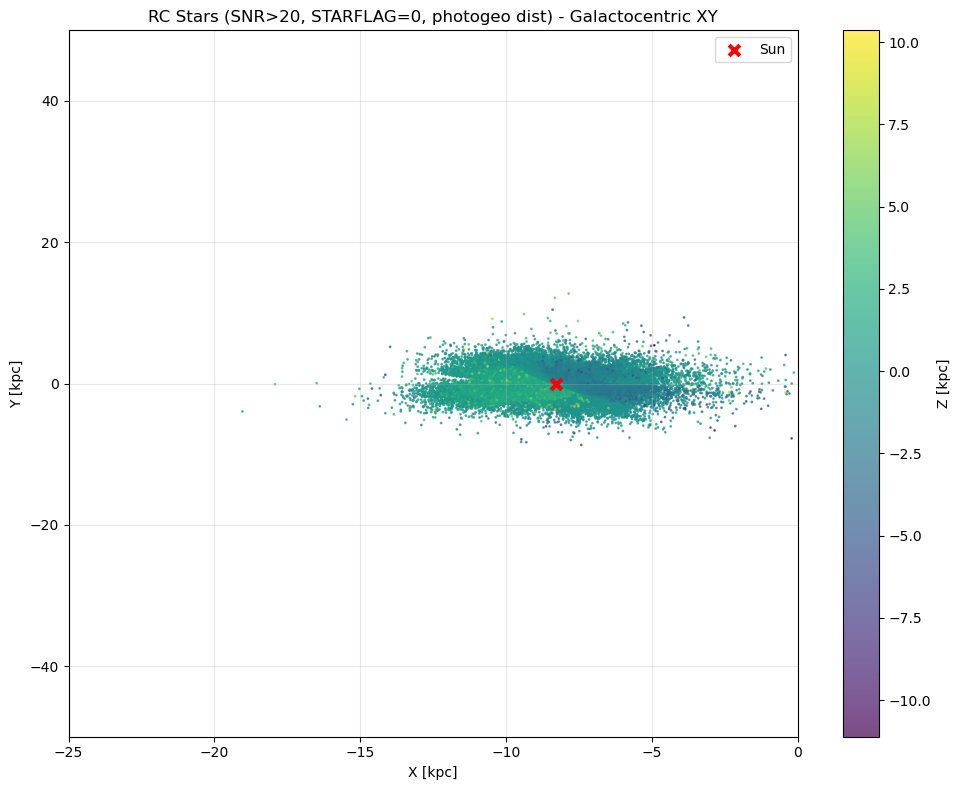

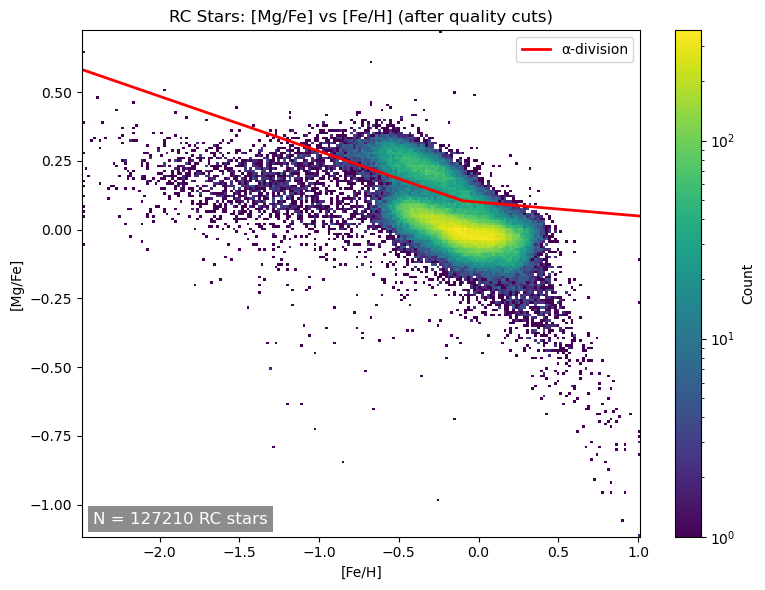

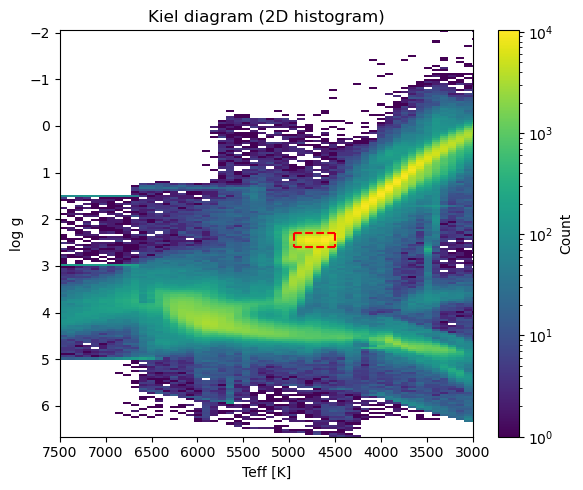

In [5]:
# ============================================================
# Full end-to-end pipeline:
#   1) Load SDSS-V / ASPCAP table
#   2) Red Clump (RC) selection in Teff–logg (Kiel) box
#   3) QUALITY CUTS (with comments):
#        - SNR > 20 (basic spectral quality)
#        - STARFLAG == 0 (remove "bad star"/problematic spectra)
#        - finite 6D inputs (ra, dec, pm, RV) for Galactocentric transform
#        - photogeometric distance present + positive (r_med_photogeo)
#        - OPTIONAL: photogeo fractional distance error cut using r_lo/r_hi
#   4) Compute Galactocentric x,y,z,vx,vy,vz using r_med_photogeo distance
#   5) Compute [Mg/Fe] and apply a piecewise low-α / high-α separation
#   6) Make 3 plots: XY colored by Z, MgFe–FeH with division, Kiel diagram
# ============================================================

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import astropy.units as u
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord, Distance

# -----------------------------
# 0) Load table
# -----------------------------
t = Table.read('astraAllStarASPCAP-0.8.fits.gz', format='fits', hdu=2)

# -----------------------------
# 1) Pull needed columns as arrays
# -----------------------------
teff = np.asarray(t['teff'], float)
logg = np.asarray(t['logg'], float)
feh  = np.asarray(t['fe_h'], float)
mgh  = np.asarray(t['mg_h'], float)
snr  = np.asarray(t['snr'], float)

ra   = np.asarray(t['ra'], float)
dec  = np.asarray(t['dec'], float)
pmra = np.asarray(t['pmra'], float)
pmde = np.asarray(t['pmde'], float)
vrad = np.asarray(t['v_rad'], float)

# Photogeometric distance (you said you want to use this)
rmed = np.asarray(t['r_med_photogeo'], float)  # commonly in pc

# Optional photogeo lo/hi bounds (may not exist)
has_lohi = ('r_lo_photogeo' in t.colnames) and ('r_hi_photogeo' in t.colnames)
if has_lohi:
    rlo = np.asarray(t['r_lo_photogeo'], float)
    rhi = np.asarray(t['r_hi_photogeo'], float)
else:
    rlo = rhi = None

# -----------------------------
# 2) Find STARFLAG column & build STARFLAG==0 mask
#    QUALITY CUT: STARFLAG == 0 removes problematic/bad spectra
# -----------------------------
possible_starflag_cols = ['flag_bad']
starflag_col = next((c for c in possible_starflag_cols if c in t.colnames), None)
if starflag_col is None:
    raise KeyError("No STARFLAG column found. Check t.colnames for the correct name (e.g., 'STARFLAG' or 'starflag').")

starflag = np.asarray(t[starflag_col])
starflag_mask = (starflag == 0)

print(f"Using STARFLAG column: {starflag_col}")
print(f"Stars passing STARFLAG==0: {int(np.sum(starflag_mask))}")

# -----------------------------
# 3) Basic finiteness masks
# -----------------------------
finite_basic = np.isfinite(teff) & np.isfinite(logg)
finite_chem  = finite_basic & np.isfinite(feh) & np.isfinite(mgh) & np.isfinite(snr)
# ----------------------------------------
# Remove cluster members (GCs, OCs, dSphs)
# ----------------------------------------
member_flags = np.asarray(t['sdss4_apogee_member_flags'], dtype=np.int64)

no_cluster = (member_flags == 0)

# -----------------------------
# 4) Red Clump (RC) Kiel box selection
# -----------------------------
teff_min, teff_max = 4950.0, 4500.0   # NOTE: teff_min > teff_max (you want 4500 <= Teff <= 4950)
logg_min, logg_max = 2.3, 2.6

rc_box_mask = (
    (teff >= teff_max) & (teff <= teff_min) &
    (logg >= logg_min) & (logg <= logg_max)
)

# -----------------------------
# 5) QUALITY CUTS to apply BEFORE slicing the table
# -----------------------------

# QUALITY CUT: SNR > 20
# - removes very noisy spectra where parameters/abundances are unreliable
snr_mask = (snr > 20)

# QUALITY CUT: photogeometric distance present and positive
# - ensures distance-based positions/velocities are meaningful
dist_mask = np.isfinite(rmed) & (rmed > 0)

# OPTIONAL QUALITY CUT: photogeo fractional distance uncertainty
# - tighter distance reliability; common to start with 20%
# - only applied if r_lo_photogeo and r_hi_photogeo exist
frac_cut = 0.20
if has_lohi:
    frac_dist_err = 0.5 * (rhi - rlo) / rmed
    dist_mask = dist_mask & np.isfinite(frac_dist_err) & (frac_dist_err < frac_cut)
    print(f"Using photogeo fractional distance cut: 0.5*(r_hi-r_lo)/r_med < {frac_cut:.2f}")
else:
    print("No r_lo_photogeo/r_hi_photogeo columns found — skipping fractional distance-error cut.")

# QUALITY CUT: finite 6D inputs needed for Galactocentric transform
# - if any of these are NaN, the coordinate transform will fail or give NaNs
kin_mask = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(pmra) & np.isfinite(pmde) &
    np.isfinite(vrad)
)

# -----------------------------
# 6) Master mask = everything combined
# -----------------------------
master_mask = (
    finite_chem &        # finite Teff/logg/FeH/MgH/SNR
    rc_box_mask &        # RC Kiel box
    snr_mask &           # QUALITY: SNR > 20
    starflag_mask &      # QUALITY: STARFLAG == 0 (bad-star removal)
    no_cluster &  
    dist_mask &          # QUALITY: valid photogeo distance (and optional frac_err cut)
    kin_mask             # QUALITY: finite 6D kinematic inputs
)

t_sel = t[master_mask]
print("Final selected sample size:", len(t_sel))

# -----------------------------
# 7) Build SkyCoord using photogeo distance
#    ASSUMPTION: r_med_photogeo is in pc (most common).
#    If your catalog says kpc instead, change u.pc -> u.kpc.
# -----------------------------
dist = Distance(np.asarray(t_sel['r_med_photogeo'], float) * u.pc)

c = SkyCoord(
    ra=np.asarray(t_sel['ra'], float) * u.deg,
    dec=np.asarray(t_sel['dec'], float) * u.deg,
    distance=dist,
    pm_ra_cosdec=np.asarray(t_sel['pmra'], float) * u.mas/u.yr,
    pm_dec=np.asarray(t_sel['pmde'], float) * u.mas/u.yr,
    radial_velocity=np.asarray(t_sel['v_rad'], float) * u.km/u.s,
)

galcen_frame = coord.Galactocentric(
    galcen_distance=8.275 * u.kpc,
    galcen_v_sun=[8, 254, 8] * u.km/u.s
)
galcen = c.transform_to(galcen_frame)

x = galcen.x.to_value(u.kpc)
y = galcen.y.to_value(u.kpc)
z = galcen.z.to_value(u.kpc)
vx = galcen.v_x.to_value(u.km/u.s)
vy = galcen.v_y.to_value(u.km/u.s)
vz = galcen.v_z.to_value(u.km/u.s)

# -----------------------------
# 8) Chemistry: [Mg/Fe] and low-α / high-α separation
# -----------------------------
fe   = np.asarray(t_sel['fe_h'], float)
mgfe = np.asarray(t_sel['mg_h'], float) - fe

finite_alpha = np.isfinite(fe) & np.isfinite(mgfe)
fe, mgfe = fe[finite_alpha], mgfe[finite_alpha]

# keep coords aligned with chemistry finiteness
x_a, y_a, z_a = x[finite_alpha], y[finite_alpha], z[finite_alpha]

# Piecewise alpha division (one source of truth)
fe_break = -0.1
m1, b1 = -0.05, 0.10
m2 = -0.20
b2 = (m1 * fe_break + b1) - m2 * fe_break  # continuity

def mgfe_dividing_line(feh_vals):
    feh_vals = np.asarray(feh_vals, float)
    return np.where(feh_vals >= fe_break, m1*feh_vals + b1, m2*feh_vals + b2)

mgfe_div = mgfe_dividing_line(fe)
low_alpha  = mgfe < mgfe_div
high_alpha = ~low_alpha

print("Low-α count:", int(np.sum(low_alpha)))
print("High-α count:", int(np.sum(high_alpha)))

# -----------------------------
# 9) Plot 1: XY colored by Z
# -----------------------------
plt.figure(figsize=(10, 8))
plt.scatter(x, y, c=z, s=1, alpha=0.7, cmap='viridis')
plt.colorbar(label='Z [kpc]')
plt.scatter(-8.275, 0, marker='x', s=60, c='red', linewidths=3, label='Sun', zorder=5)

plt.xlabel('X [kpc]')
plt.ylabel('Y [kpc]')
plt.title('RC Stars (SNR>20, STARFLAG=0, photogeo dist) - Galactocentric XY')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(-25, 0)
plt.ylim(-50, 50)
plt.tight_layout()
plt.show()

# -----------------------------
# 10) Plot 2: Mg/Fe vs Fe/H + α division
# -----------------------------
plt.figure(figsize=(8, 6))
plt.hist2d(fe, mgfe, bins=200, norm=LogNorm(), cmap='viridis')
plt.colorbar(label='Count')

fe_grid = np.linspace(np.nanmin(fe), np.nanmax(fe), 400)
plt.plot(fe_grid, mgfe_dividing_line(fe_grid), color='red', lw=2, label='α-division')

plt.text(
    0.02, 0.02,
    f"N = {len(fe)} RC stars",
    transform=plt.gca().transAxes,
    fontsize=12,
    va='bottom',
    color='white',
    bbox=dict(facecolor='grey', alpha=0.9, edgecolor='none', pad=4)
)

plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.title('RC Stars: [Mg/Fe] vs [Fe/H] (after quality cuts)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# -----------------------------
# 11) Plot 3: Kiel diagram (full sample) + RC box overlay
# -----------------------------
x_all = teff[finite_basic]
y_all = logg[finite_basic]

xr = (np.nanmin(x_all), np.nanmax(x_all))
yr = (np.nanmin(y_all), np.nanmax(y_all))

plt.figure(figsize=(6, 5))
plt.hist2d(x_all, y_all, bins=200, range=[xr, yr], norm=LogNorm(), cmap='viridis')
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.colorbar(label='Count')

plt.xlabel('Teff [K]')
plt.ylabel('log g')
plt.xlim(7500, 3000)
plt.title('Kiel diagram (2D histogram)')

# RC selection box
plt.hlines([logg_min, logg_max], teff_max, teff_min, colors='red', linestyles='--')
plt.vlines([teff_max, teff_min], logg_min, logg_max, colors='red', linestyles='--')

plt.tight_layout()
plt.savefig("kiel.png", dpi=300, bbox_inches="tight")
plt.show()

Finite points: 123951
Inside triangle: 87924
Triangle-selected sample: 87924


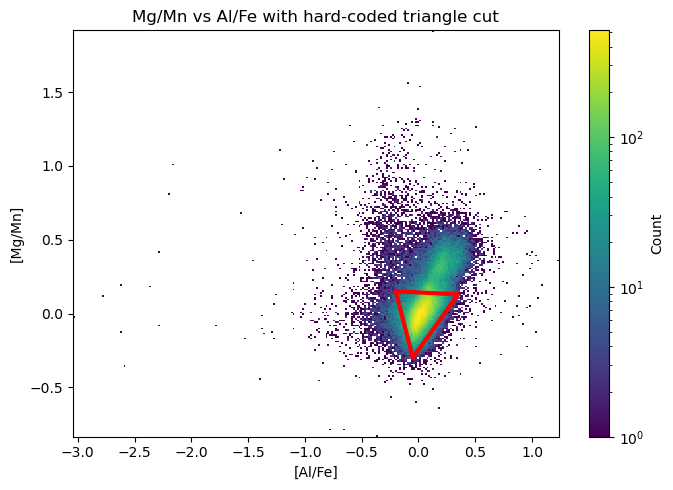

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.path import Path

# axes: x = [Al/Fe], y = [Mg/Mn]
alfe = np.asarray(t_sel['al_h'], float) - np.asarray(t_sel['fe_h'], float)
mgmn = np.asarray(t_sel['mg_h'], float) - np.asarray(t_sel['mn_h'], float)

finite = np.isfinite(alfe) & np.isfinite(mgmn)
x = alfe[finite]
y = mgmn[finite]
tri_vertices = np.array([
    [-0.2,  0.15],   # top-left-ish 
    [0.35,  0.13],   # right vertex
    [-0.05, -0.3],   # bottom vertex
    ])

tri_path = Path(tri_vertices)
pts = np.vstack([x, y]).T

inside = tri_path.contains_points(pts)

# map back to full length of t_sel
tri_mask_full = np.zeros(len(t_sel), dtype=bool)
tri_mask_full[np.where(finite)[0]] = inside

t_triangle = t_sel[tri_mask_full]

print("Finite points:", len(pts))
print("Inside triangle:", int(np.sum(inside)))
print("Triangle-selected sample:", len(t_triangle))
plt.figure(figsize=(7,5))
plt.hist2d(x, y, bins=250, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Count")
plt.xlabel("[Al/Fe]")
plt.ylabel("[Mg/Mn]")
plt.title("Mg/Mn vs Al/Fe with hard-coded triangle cut")

# draw triangle
closed = np.vstack([tri_vertices, tri_vertices[0]])
plt.plot(closed[:,0], closed[:,1], color="red", lw=3)

# highlight selected points
#plt.scatter(x[inside], y[inside], s=2, alpha=0.35, color="red")

plt.tight_layout()
plt.show()


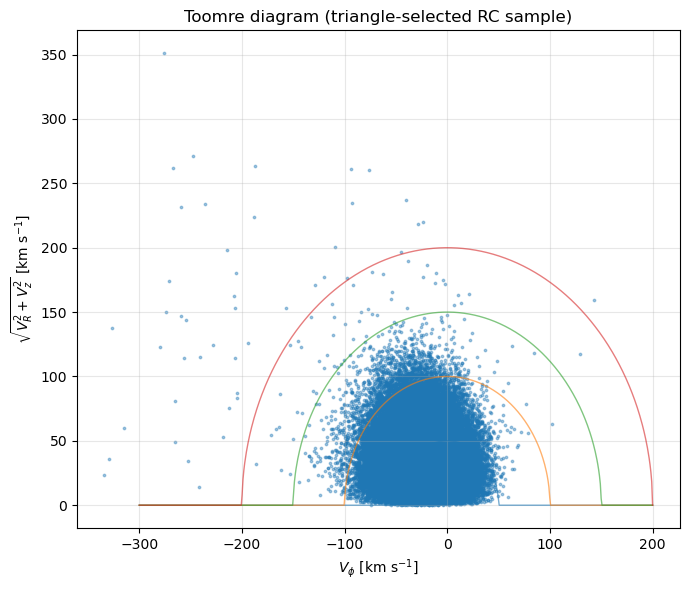

Median |V_LSR|: 23.59875678683703
Median sqrt(U^2+W^2): 30.279891894868378


In [7]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord, Distance
from matplotlib.colors import LogNorm

# ------------------------------------------------------------
# Build SkyCoord for your final sample (e.g., t_triangle)
# ------------------------------------------------------------
dist = Distance(np.asarray(t_triangle['r_med_photogeo'], float) * u.pc)

c = SkyCoord(
    ra=np.asarray(t_triangle['ra'], float) * u.deg,
    dec=np.asarray(t_triangle['dec'], float) * u.deg,
    distance=dist,
    pm_ra_cosdec=np.asarray(t_triangle['pmra'], float) * u.mas/u.yr,
    pm_dec=np.asarray(t_triangle['pmde'], float) * u.mas/u.yr,
    radial_velocity=np.asarray(t_triangle['v_rad'], float) * u.km/u.s,
)

galcen_frame = coord.Galactocentric(
    galcen_distance=8.275 * u.kpc,
    galcen_v_sun=[8, 254, 8] * u.km/u.s
)

gc = c.transform_to(galcen_frame)

# ------------------------------------------------------------
# Pull Cartesian positions/velocities (km/s, kpc)
# ------------------------------------------------------------
x  = gc.x.to_value(u.kpc)
y  = gc.y.to_value(u.kpc)
z  = gc.z.to_value(u.kpc)

vx = gc.v_x.to_value(u.km/u.s)
vy = gc.v_y.to_value(u.km/u.s)
vz = gc.v_z.to_value(u.km/u.s)

R = np.sqrt(x**2 + y**2)

# avoid divide-by-zero if any stars are at R~0 (unlikely)
goodR = np.isfinite(R) & (R > 1e-6)
x, y, z, vx, vy, vz, R = x[goodR], y[goodR], z[goodR], vx[goodR], vy[goodR], vz[goodR], R[goodR]

# ------------------------------------------------------------
# Cylindrical velocities from Cartesian
# vR  = (x vx + y vy)/R
# vphi = (-x vy + y vx)/R   (right-handed, rotation direction)
# vz  = vz
# ------------------------------------------------------------
vR   = (x*vx + y*vy) / R
vphi = (-x*vy + y*vx) / R
vz   = vz

# ------------------------------------------------------------
# Toomre variables relative to (your) Sun rotation choice
# Using your galcen_v_sun=[8,254,8] -> take vphi_sun ~ 254 km/s
# ------------------------------------------------------------
vphi_sun = 254.0

U_lsr = -vR
V_lsr = vphi - vphi_sun
W_lsr = vz

T = np.sqrt(U_lsr**2 + W_lsr**2)

# ------------------------------------------------------------
# Plot Toomre
# x = V_LSR, y = sqrt(U^2 + W^2)
# ------------------------------------------------------------
plt.figure(figsize=(7,6))
plt.scatter(V_lsr, T, s=3, alpha=0.4)

plt.xlabel(r'$V_\phi$ [km s$^{-1}$]')
plt.ylabel(r'$\sqrt{V_R^2 + V_z^2}$ [km s$^{-1}$]')
plt.title("Toomre diagram (triangle-selected RC sample)")

# reference circles of constant total velocity: Vtot^2 = T^2 + V^2
Vgrid = np.linspace(-300, 200, 600)
for vtot in [50, 100, 150, 200]:
    Tgrid = np.sqrt(np.maximum(vtot**2 - Vgrid**2, 0))
    plt.plot(Vgrid, Tgrid, lw=1, alpha=0.6)

#plt.xlim(-300, 200)
#plt.ylim(0, 300)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Median |V_LSR|:", np.nanmedian(np.abs(V_lsr)))
print("Median sqrt(U^2+W^2):", np.nanmedian(T))


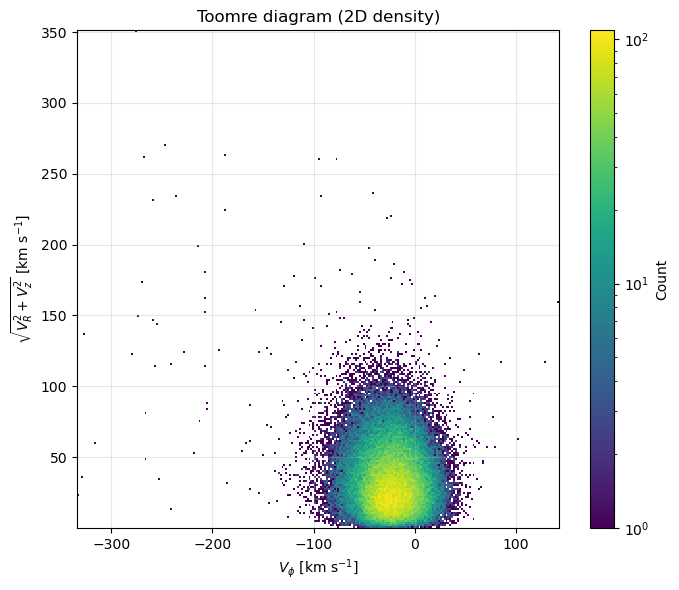

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.figure(figsize=(7,6))
plt.hist2d(V_lsr, T, bins=250, norm=LogNorm())
plt.colorbar(label="Count")

plt.xlabel(r'$V_\phi$ [km s$^{-1}$]')
plt.ylabel(r'$\sqrt{V_R^2 + V_z^2}$ [km s$^{-1}$]')
plt.title("Toomre diagram (2D density)")

#plt.xlim(-300, 200)
#plt.ylim(0, 300)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

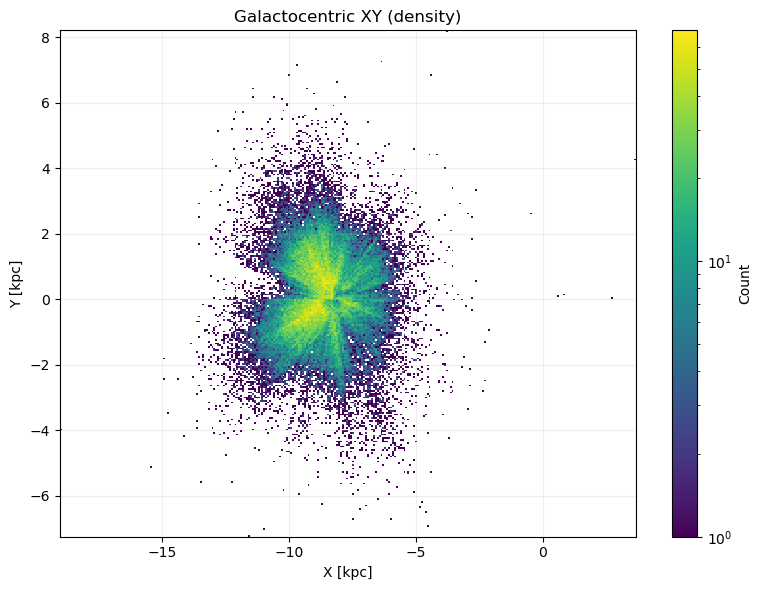

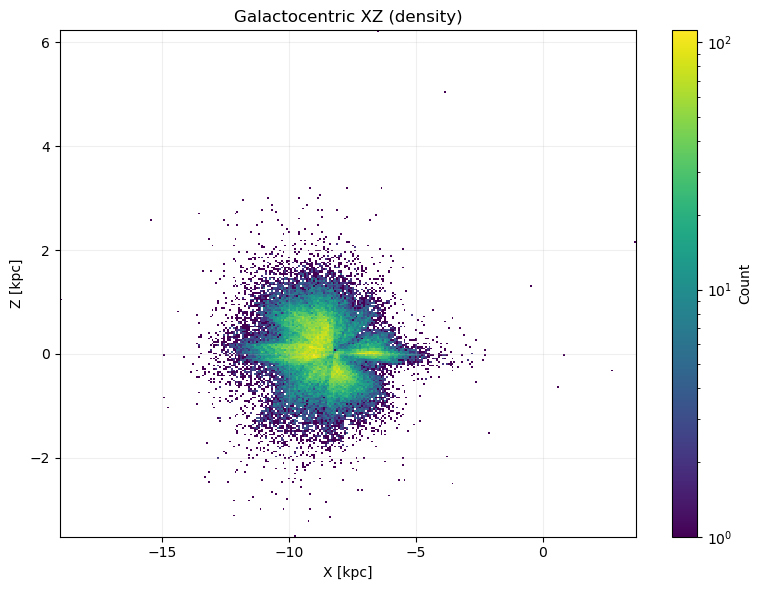

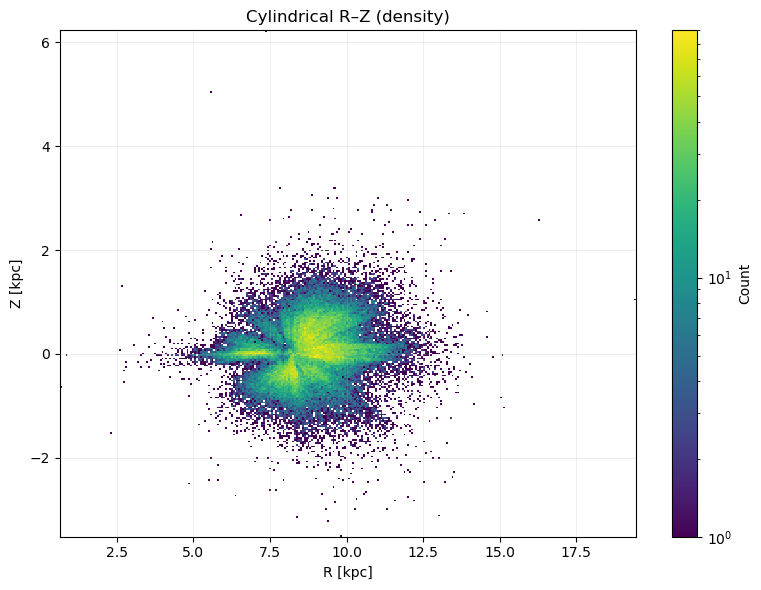

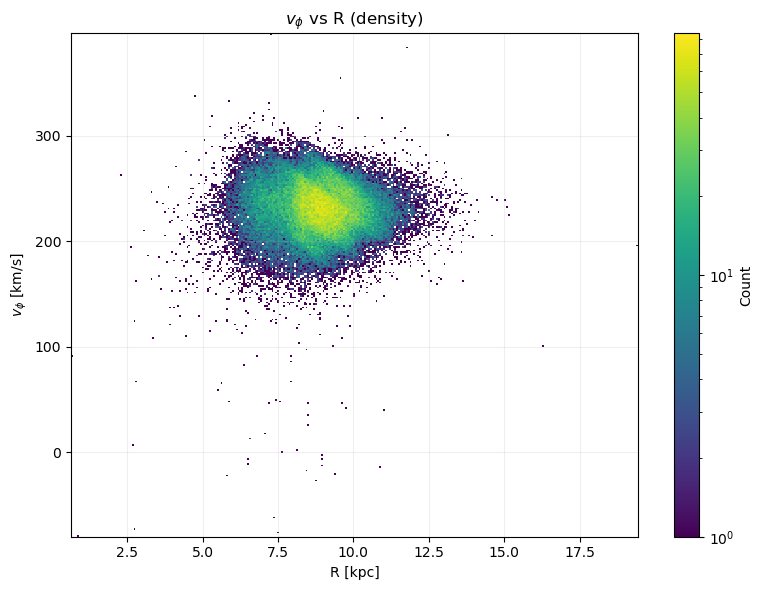

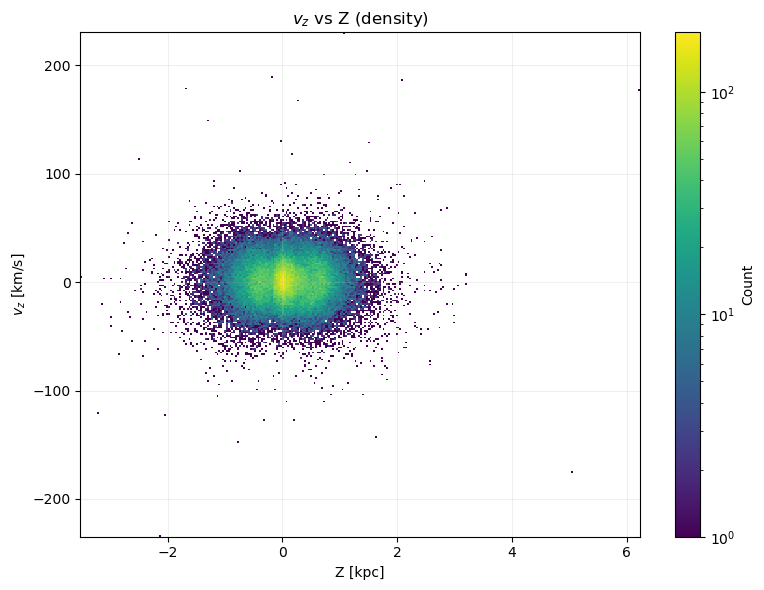

N stars in phase-space maps: 87924
R range [kpc]: 0.6433889708237052 to 19.445566258691038
Z range [kpc]: -3.51944024671571 to 6.231707215787308
Median vphi [km/s]: 231.3046142963501
Median |vz| [km/s]: 11.191919006097072


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.units as u
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord, Distance

t_final = t_triangle  

# ------------------------------------------------------------
# 1) Build SkyCoord and transform to Galactocentric
# ------------------------------------------------------------
dist = Distance(np.asarray(t_final['r_med_photogeo'], float) * u.pc)  # change to u.kpc if needed

c = SkyCoord(
    ra=np.asarray(t_final['ra'], float) * u.deg,
    dec=np.asarray(t_final['dec'], float) * u.deg,
    distance=dist,
    pm_ra_cosdec=np.asarray(t_final['pmra'], float) * u.mas/u.yr,
    pm_dec=np.asarray(t_final['pmde'], float) * u.mas/u.yr,
    radial_velocity=np.asarray(t_final['v_rad'], float) * u.km/u.s,
)

galcen_frame = coord.Galactocentric(
    galcen_distance=8.275 * u.kpc,
    galcen_v_sun=[8, 254, 8] * u.km/u.s
)

gc = c.transform_to(galcen_frame)

# Cartesian positions/velocities
X  = gc.x.to_value(u.kpc)
Y  = gc.y.to_value(u.kpc)
Z  = gc.z.to_value(u.kpc)
VX = gc.v_x.to_value(u.km/u.s)
VY = gc.v_y.to_value(u.km/u.s)
VZ = gc.v_z.to_value(u.km/u.s)

# ------------------------------------------------------------
# 2) Cylindrical coordinates and velocities (computed from Cartesian)
# ------------------------------------------------------------
R   = np.sqrt(X**2 + Y**2)
phi = np.arctan2(Y, X)  # radians

# Avoid divide-by-zero for any tiny-R points
good = np.isfinite(R) & (R > 1e-6)
X, Y, Z, VX, VY, VZ, R, phi = X[good], Y[good], Z[good], VX[good], VY[good], VZ[good], R[good], phi[good]

# Cylindrical velocities
vR   = (X*VX + Y*VY) / R
vphi = (-X*VY + Y*VX) / R
vz   = VZ

# ------------------------------------------------------------
# 3) Plots: 3D phase space views (2D projections + velocity coloring)
# ------------------------------------------------------------

# --- A) XY density colored by Z (or just density) ---
plt.figure(figsize=(8,6))
plt.hist2d(X, Y, bins=300, norm=LogNorm())
plt.colorbar(label="Count")
plt.xlabel("X [kpc]")
plt.ylabel("Y [kpc]")
plt.title("Galactocentric XY (density)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# --- B) XZ density ---
plt.figure(figsize=(8,6))
plt.hist2d(X, Z, bins=300, norm=LogNorm())
plt.colorbar(label="Count")
plt.xlabel("X [kpc]")
plt.ylabel("Z [kpc]")
plt.title("Galactocentric XZ (density)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# --- C) R–Z density (nice for disk structure) ---
plt.figure(figsize=(8,6))
plt.hist2d(R, Z, bins=300, norm=LogNorm())
plt.colorbar(label="Count")
plt.xlabel("R [kpc]")
plt.ylabel("Z [kpc]")
plt.title("Cylindrical R–Z (density)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# --- D) Velocity structure: vphi vs R (rotation curve-ish sanity check) ---
plt.figure(figsize=(8,6))
plt.hist2d(R, vphi, bins=300, norm=LogNorm())
plt.colorbar(label="Count")
plt.xlabel("R [kpc]")
plt.ylabel(r"$v_\phi$ [km/s]")
plt.title(r"$v_\phi$ vs R (density)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# --- E) Velocity dispersion sanity: vz vs Z ---
plt.figure(figsize=(8,6))
plt.hist2d(Z, vz, bins=300, norm=LogNorm())
plt.colorbar(label="Count")
plt.xlabel("Z [kpc]")
plt.ylabel(r"$v_z$ [km/s]")
plt.title(r"$v_z$ vs Z (density)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("N stars in phase-space maps:", len(X))
print("R range [kpc]:", np.nanmin(R), "to", np.nanmax(R))
print("Z range [kpc]:", np.nanmin(Z), "to", np.nanmax(Z))
print("Median vphi [km/s]:", np.nanmedian(vphi))
print("Median |vz| [km/s]:", np.nanmedian(np.abs(vz)))


N stars available for Mg/Fe–Z: 87924

Annulus 7.5–8.0 kpc: N=6936


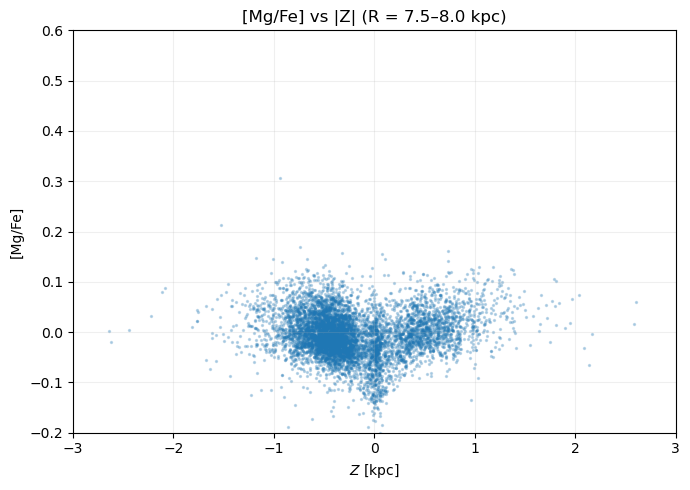


Annulus 8.0–8.5 kpc: N=13056


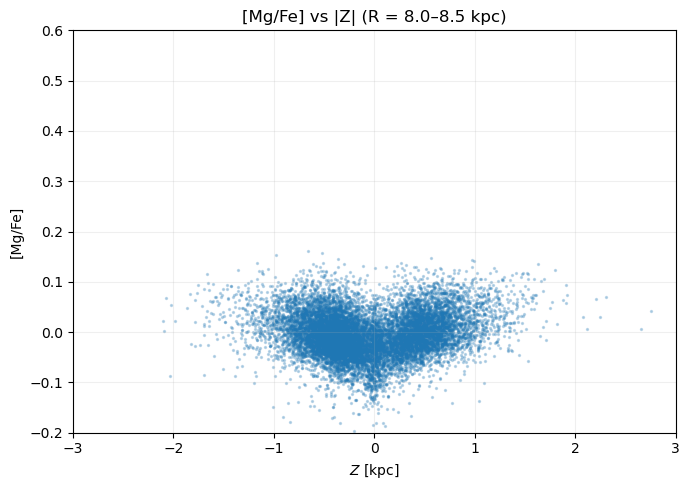


Annulus 8.5–9.0 kpc: N=16545


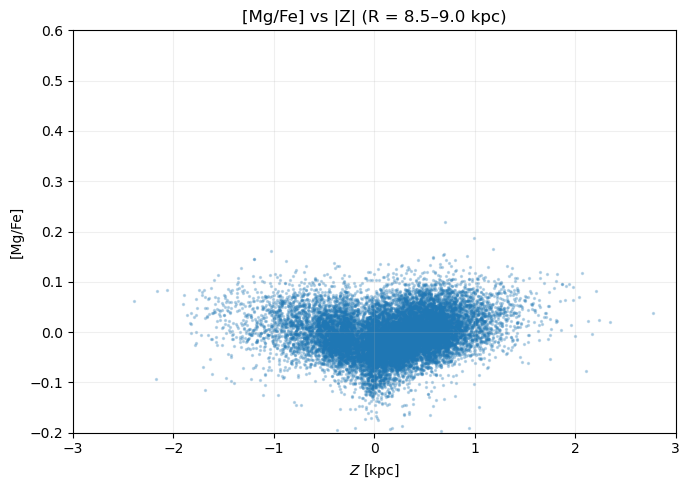

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.units as u
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord, Distance

# ------------------------------------------------------------
# Choose your final sample table (after all cuts)
# ------------------------------------------------------------
t_final = t_triangle   # or t_sel

# ------------------------------------------------------------
# Build Galactocentric positions/velocities (you already do this)
# ------------------------------------------------------------
dist = Distance(np.asarray(t_final['r_med_photogeo'], float) * u.pc)  # change u.pc->u.kpc if needed

c = SkyCoord(
    ra=np.asarray(t_final['ra'], float) * u.deg,
    dec=np.asarray(t_final['dec'], float) * u.deg,
    distance=dist,
    pm_ra_cosdec=np.asarray(t_final['pmra'], float) * u.mas/u.yr,
    pm_dec=np.asarray(t_final['pmde'], float) * u.mas/u.yr,
    radial_velocity=np.asarray(t_final['v_rad'], float) * u.km/u.s,
)

galcen_frame = coord.Galactocentric(
    galcen_distance=8.275 * u.kpc,
    galcen_v_sun=[8, 254, 8] * u.km/u.s
)
gc = c.transform_to(galcen_frame)

X = gc.x.to_value(u.kpc)
Y = gc.y.to_value(u.kpc)
Z = gc.z.to_value(u.kpc)

R = np.sqrt(X**2 + Y**2)

# ------------------------------------------------------------
# Chemistry: [Mg/Fe]
# ------------------------------------------------------------
feh = np.asarray(t_final['fe_h'], float)
mgh = np.asarray(t_final['mg_h'], float)
mgfe = mgh - feh

finite = np.isfinite(R) & np.isfinite(Z) & np.isfinite(mgfe)
R, Z, mgfe = R[finite], Z[finite], mgfe[finite]
absZ = np.abs(Z)

print("N stars available for Mg/Fe–Z:", len(mgfe))

# ------------------------------------------------------------
# User-tunable: define "local solar neighborhood" as narrow annuli
# (full azimuth, large vertical extent)
# ------------------------------------------------------------
R0 = 8.275
annuli = [
    (7.5, 8.0),
    (8.0, 8.5),
    (8.5, 9.0),
]
# Alternative single solar annulus:
# annuli = [(7.75, 8.75)]

# Vertical extent: keep large (or set a cap just to avoid insane outliers)
Zmax = 5.0   # kpc; set to None to keep all
if Zmax is not None:
    zmask = absZ < Zmax
else:
    zmask = np.ones_like(Z, dtype=bool)

# ------------------------------------------------------------
# Helper: column-normalized 2D histogram (normalize each |Z| bin)
# x = |Z|, y = [Mg/Fe]
# ------------------------------------------------------------
def column_normalized_hist2d(x, y, x_edges, y_edges):
    H, xe, ye = np.histogram2d(x, y, bins=[x_edges, y_edges])  # H shape = (nx, ny)
    # Normalize each x-column (each |Z| bin) so sum_y = 1
    colsum = H.sum(axis=1, keepdims=True)
    Hnorm = np.divide(H, colsum, out=np.zeros_like(H), where=(colsum > 0))
    return Hnorm.T, xe, ye  # transpose so y is vertical axis for imshow/pcolormesh

# Bin choices
z_edges = np.linspace(-3.0, 3.0, 121)        # |Z| from 0 to 3 kpc (edit as needed)
mgfe_edges = np.linspace(-0.2, 0.6, 81)    # [Mg/Fe] range (edit as needed)

# ------------------------------------------------------------
# Loop over annuli: scatter + column-normalized density
# ------------------------------------------------------------
for (Rmin, Rmax) in annuli:
    ann_mask = zmask & (R >= Rmin) & (R < Rmax)

    zz = Z[ann_mask]
    yy = mgfe[ann_mask]

    print(f"\nAnnulus {Rmin:.1f}–{Rmax:.1f} kpc: N={len(yy)}")

    # --- 1) Scatter: [Mg/Fe] vs |Z| ---
    plt.figure(figsize=(7,5))
    plt.scatter(zz, yy, s=2, alpha=0.25)
    plt.xlabel(r"$Z$ [kpc]")
    plt.ylabel(r"[Mg/Fe]")
    plt.title(f"[Mg/Fe] vs |Z| (R = {Rmin:.1f}–{Rmax:.1f} kpc)")
    plt.xlim(z_edges[0], z_edges[-1])
    plt.ylim(mgfe_edges[0], mgfe_edges[-1])
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()



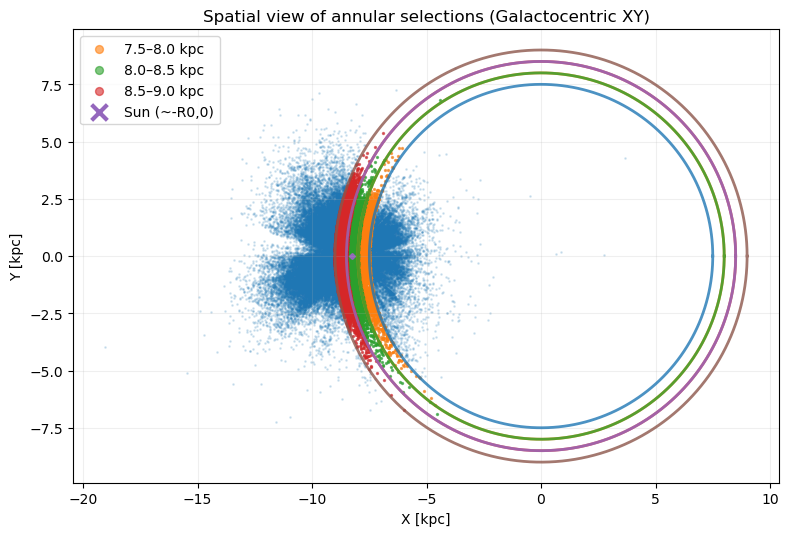

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord, Distance

# -----------------------------
# Pick final sample
# -----------------------------
t_final = t_triangle  # or t_sel

# -----------------------------
# Build Galactocentric coords
# -----------------------------
dist = Distance(np.asarray(t_final['r_med_photogeo'], float) * u.pc)  # change to u.kpc if needed

c = SkyCoord(
    ra=np.asarray(t_final['ra'], float) * u.deg,
    dec=np.asarray(t_final['dec'], float) * u.deg,
    distance=dist,
    pm_ra_cosdec=np.asarray(t_final['pmra'], float) * u.mas/u.yr,
    pm_dec=np.asarray(t_final['pmde'], float) * u.mas/u.yr,
    radial_velocity=np.asarray(t_final['v_rad'], float) * u.km/u.s,
)

galcen_frame = coord.Galactocentric(
    galcen_distance=8.275 * u.kpc,
    galcen_v_sun=[8, 254, 8] * u.km/u.s
)
gc = c.transform_to(galcen_frame)

X = gc.x.to_value(u.kpc)
Y = gc.y.to_value(u.kpc)
Z = gc.z.to_value(u.kpc)
R = np.sqrt(X**2 + Y**2)
absZ = np.abs(Z)

# -----------------------------
# Define annuli (edit these)
# -----------------------------
annuli = [
    (7.5, 8.0),
    (8.0, 8.5),
    (8.5, 9.0),
]
Zmax = 5.0  # “large vertical extent”; just a safety cap
base_mask = np.isfinite(X) & np.isfinite(Y) & np.isfinite(R) & np.isfinite(absZ) & (absZ < Zmax)

# -----------------------------
# Plot: XY with annuli boundaries + highlighted stars
# -----------------------------
plt.figure(figsize=(8,8))

# All stars in light grey (context)
plt.scatter(X[base_mask], Y[base_mask], s=1, alpha=0.15)

# Draw circles for each annulus boundary
theta = np.linspace(0, 2*np.pi, 600)
for (Rmin, Rmax) in annuli:
    # boundaries
    plt.plot(Rmin*np.cos(theta), Rmin*np.sin(theta), lw=2, alpha=0.8)
    plt.plot(Rmax*np.cos(theta), Rmax*np.sin(theta), lw=2, alpha=0.8)

# Highlight stars in each annulus (one scatter call per annulus)
for (Rmin, Rmax) in annuli:
    m = base_mask & (R >= Rmin) & (R < Rmax)
    plt.scatter(X[m], Y[m], s=2, alpha=0.6, label=f"{Rmin:.1f}–{Rmax:.1f} kpc")
    
# Sun marker in Galactocentric XY:
# In this Galactocentric convention, the Sun sits at approximately (-R0, 0).
R0 = 8.275
plt.scatter(-R0, 0, marker='x', s=8, linewidths=3, label="Sun (~-R0,0)")

plt.gca().set_aspect("equal", "box")
plt.xlabel("X [kpc]")
plt.ylabel("Y [kpc]")
plt.title("Spatial view of annular selections (Galactocentric XY)")
plt.grid(alpha=0.2)
plt.legend(markerscale=4, frameon=True)
plt.tight_layout()
plt.show()


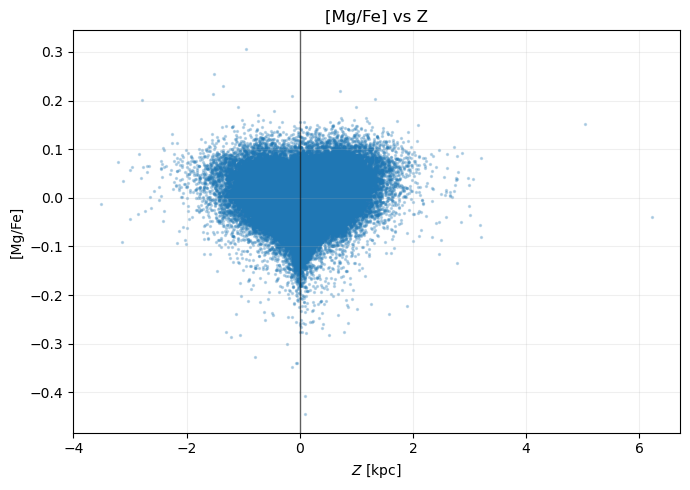

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Signed Z (kpc)
Z = gc.z.to_value(u.kpc)

# Chemistry
feh = np.asarray(t_final['fe_h'], float)
mgh = np.asarray(t_final['mg_h'], float)
mgfe = mgh - feh

finite = np.isfinite(Z) & np.isfinite(mgfe)
Z, mgfe = Z[finite], mgfe[finite]

# -----------------------------
# 1) Scatter: Mg/Fe vs signed Z
# -----------------------------
plt.figure(figsize=(7,5))
plt.scatter(Z, mgfe, s=2, alpha=0.25)

plt.axvline(0, color='k', lw=1, alpha=0.6)  # midplane
plt.xlabel(r"$Z$ [kpc]")
plt.ylabel(r"[Mg/Fe]")
plt.title("[Mg/Fe] vs Z")
#plt.xlim(-3, 3)
#plt.ylim(-0.4, 0.6)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


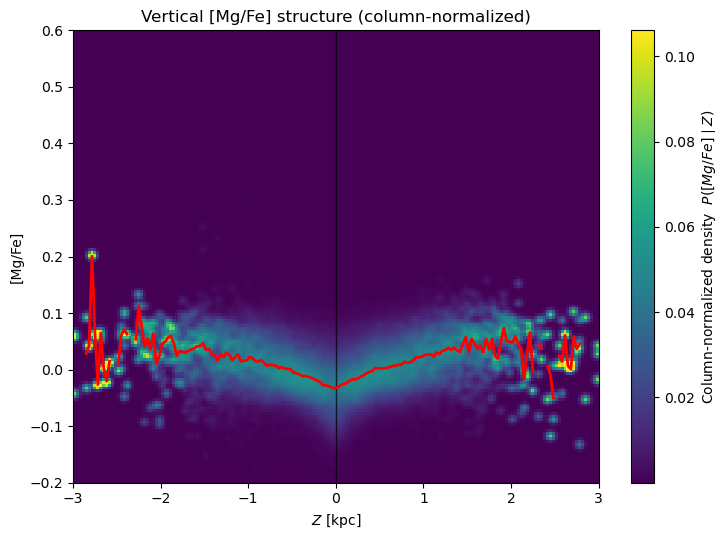

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# -----------------------------
# 1) Bins (tweak if you want)
# -----------------------------
z_edges    = np.linspace(-3.0, 3.0, 181)    # more bins -> less chunky
mgfe_edges = np.linspace(-0.2, 0.6, 161)

# -----------------------------
# 2) Column-normalized 2D histogram
#    x = Z, y = Mg/Fe
# -----------------------------
H, ze, me = np.histogram2d(Z, mgfe, bins=[z_edges, mgfe_edges])  # H shape (nz, nmgfe)

colsum = H.sum(axis=1, keepdims=True)
Hnorm  = np.divide(H, colsum, out=np.zeros_like(H), where=(colsum > 0))

# Light smoothing to reduce pixelation / speckle
Hnorm_smooth = gaussian_filter(Hnorm, sigma=(1.0, 1.0))

# For plotting with pcolormesh: transpose so Mg/Fe is vertical axis
img = Hnorm_smooth.T

# Robust color scale (prevents a few bright bins from washing out everything)
vals = img[(img > 0) & np.isfinite(img)]
vmin, vmax = np.percentile(vals, [2, 99.7]) if len(vals) else (0, 1)

# -----------------------------
# 3) Median Mg/Fe in each Z bin (no min-N, no smoothing)
# -----------------------------
z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])
med_mgfe = np.full_like(z_centers, np.nan, dtype=float)

for i in range(len(z_edges) - 1):
    m = (Z >= z_edges[i]) & (Z < z_edges[i+1])
    if np.any(m):
        med_mgfe[i] = np.nanmedian(mgfe[m])

# -----------------------------
# 4) Plot
# -----------------------------
plt.figure(figsize=(7.5, 5.5))
plt.pcolormesh(ze, me, img, shading="auto", vmin=vmin, vmax=vmax)
plt.colorbar(label=r"Column-normalized density  $P([Mg/Fe]\mid Z)$")

plt.axvline(0, color="k", lw=1, alpha=0.7)
plt.plot(z_centers, med_mgfe, color="red", lw=2)

plt.xlabel(r"$Z$ [kpc]")
plt.ylabel(r"[Mg/Fe]")
plt.title(r"Vertical [Mg/Fe] structure (column-normalized)")

plt.xlim(-3, 3)
plt.ylim(-0.2, 0.6)
plt.tight_layout()
plt.show()

In [15]:
# --- Build everything from the SAME final sample ---
t_final = t_triangle  # or whatever your final sample is

import numpy as np
import astropy.units as u
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord, Distance

dist = Distance(np.asarray(t_final['r_med_photogeo'], float) * u.pc)

c = SkyCoord(
    ra=np.asarray(t_final['ra'], float) * u.deg,
    dec=np.asarray(t_final['dec'], float) * u.deg,
    distance=dist,
    pm_ra_cosdec=np.asarray(t_final['pmra'], float) * u.mas/u.yr,
    pm_dec=np.asarray(t_final['pmde'], float) * u.mas/u.yr,
    radial_velocity=np.asarray(t_final['v_rad'], float) * u.km/u.s,
)

galcen_frame = coord.Galactocentric(
    galcen_distance=8.275 * u.kpc,
    galcen_v_sun=[8, 254, 8] * u.km/u.s
)
gc = c.transform_to(galcen_frame)

X_all = gc.x.to_value(u.kpc)
Y_all = gc.y.to_value(u.kpc)
Z_all = gc.z.to_value(u.kpc)
R_all = np.sqrt(X_all**2 + Y_all**2)

feh_all  = np.asarray(t_final['fe_h'], float)
mgh_all  = np.asarray(t_final['mg_h'], float)
mgfe_all = mgh_all - feh_all

# ONE shared mask for alignment
finite = np.isfinite(R_all) & np.isfinite(Z_all) & np.isfinite(mgfe_all)
R_all, Z_all, mgfe_all = R_all[finite], Z_all[finite], mgfe_all[finite]

print("Lengths:", len(R_all), len(Z_all), len(mgfe_all))

Lengths: 87924 87924 87924


Plotted 16 annuli with N ≥ 100


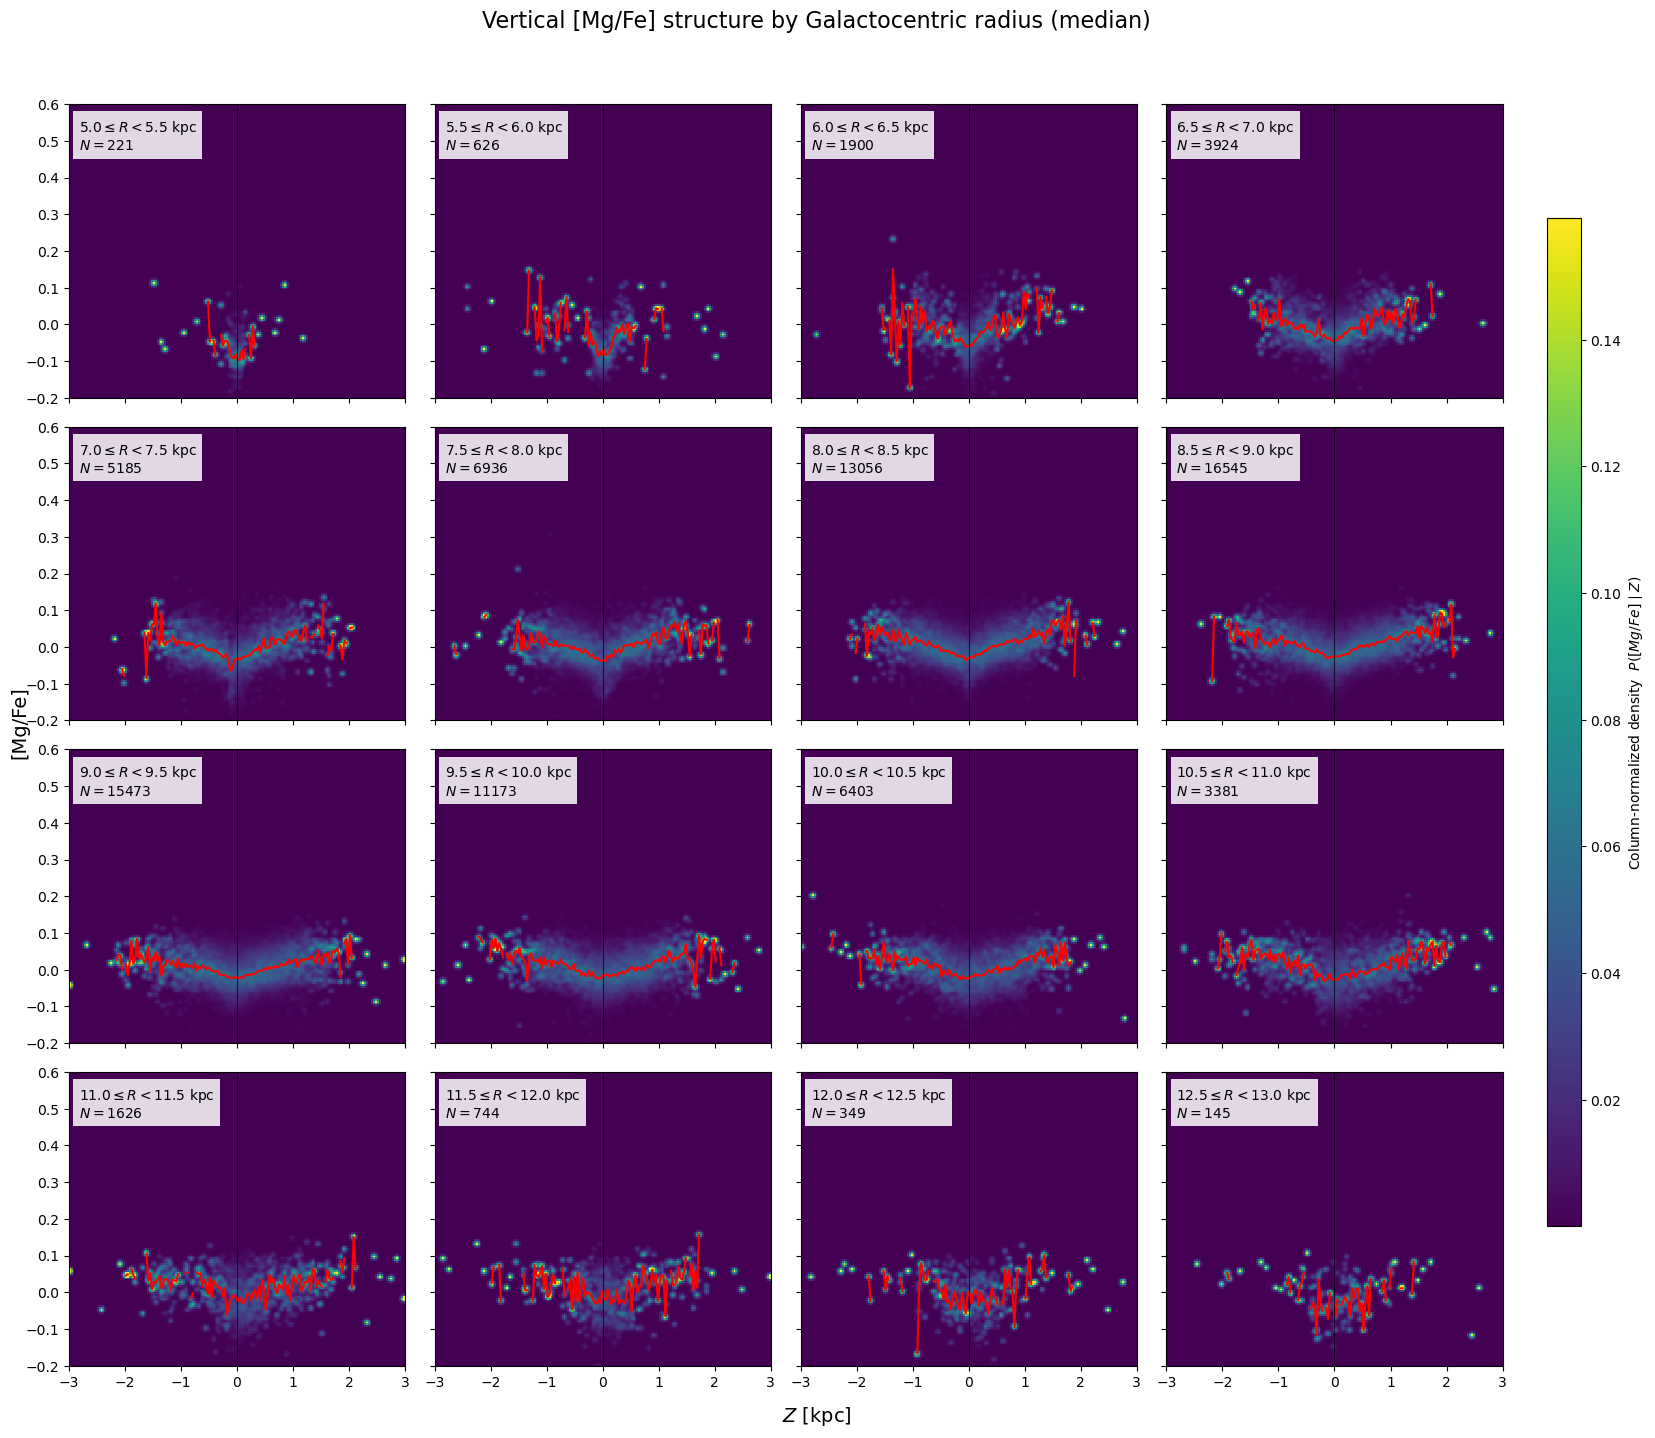

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# -----------------------------
# Assumes you already have:
#   R_all, Z_all, mgfe_all
# -----------------------------

dR = 0.5
minN = 100

Rmin_data = np.nanmin(R_all)
Rmax_data = np.nanmax(R_all)

Rstart = np.floor(Rmin_data / dR) * dR
Rstop  = np.ceil(Rmax_data / dR) * dR
all_annuli = [(r, r + dR) for r in np.arange(Rstart, Rstop, dR)]

# bins shared across panels
z_edges    = np.linspace(-3.0, 3.0, 181)
mgfe_edges = np.linspace(-0.2, 0.6, 161)
z_centers  = 0.5 * (z_edges[:-1] + z_edges[1:])

# -----------------------------
# Precompute images, medians, and N
# -----------------------------
annuli = []
imgs = []
medians = []
Ns = []

for (Rmin, Rmax) in all_annuli:
    m = (R_all >= Rmin) & (R_all < Rmax)
    N = int(np.sum(m))
    if N < minN:
        continue

    Z = Z_all[m]
    mgfe = mgfe_all[m]

    H, ze, me = np.histogram2d(Z, mgfe, bins=[z_edges, mgfe_edges])
    colsum = H.sum(axis=1, keepdims=True)
    Hnorm = np.divide(H, colsum, out=np.zeros_like(H), where=(colsum > 0))

    img = gaussian_filter(Hnorm, sigma=(1.0, 1.0)).T

    med = np.full_like(z_centers, np.nan, dtype=float)
    for i in range(len(z_edges) - 1):
        mm = (Z >= z_edges[i]) & (Z < z_edges[i+1])
        if np.any(mm):
            med[i] = np.nanmedian(mgfe[mm])

    annuli.append((Rmin, Rmax))
    imgs.append(img)
    medians.append(med)
    Ns.append(N)

print(f"Plotted {len(annuli)} annuli with N ≥ {minN}")

# Shared color scale across panels
vals = np.concatenate([img[(img > 0) & np.isfinite(img)] for img in imgs])
vmin, vmax = np.percentile(vals, [2, 99.7]) if len(vals) else (0, 1)

# -----------------------------
# Grid layout
# -----------------------------
n_panels = len(annuli)
ncols = 4
nrows = int(np.ceil(n_panels / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4.2 * ncols, 3.6 * nrows),
    sharex=True, sharey=True
)

axes = np.atleast_2d(axes)

# Plot panels
pcm = None
for i, ax in enumerate(axes.flat):
    if i >= n_panels:
        ax.axis("off")
        continue

    Rmin, Rmax = annuli[i]
    img = imgs[i]
    med = medians[i]
    N   = Ns[i]

    pcm = ax.pcolormesh(
        z_edges, mgfe_edges, img,
        shading="auto", vmin=vmin, vmax=vmax
    )

    ax.plot(z_centers, med, color="red", lw=1.5)
    ax.axvline(0, color="k", lw=0.8, alpha=0.7)

    # Label: annulus + N (same textbox)
    ax.text(
        0.03, 0.95,
        rf"${Rmin:.1f}\leq R<{Rmax:.1f}$ kpc" + "\n" + rf"$N={N}$",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )

    ax.set_xlim(-3, 3)
    ax.set_ylim(-0.2, 0.6)

# Shared labels
fig.supxlabel(r"$Z$ [kpc]", fontsize=14)
fig.supylabel(r"[Mg/Fe]", fontsize=14)
fig.suptitle(r"Vertical [Mg/Fe] structure by Galactocentric radius (median)", fontsize=16, y=0.995)

# -----------------------------
# Colorbar: put it in its own axis (no overlap)
# -----------------------------
# Leave room on the right for the colorbar
fig.tight_layout(rect=[0.0, 0.0, 0.92, 0.97])

# Add a dedicated colorbar axis: [left, bottom, width, height] in figure coords
cax = fig.add_axes([0.935, 0.15, 0.02, 0.70])
cbar = fig.colorbar(pcm, cax=cax)
cbar.set_label(r"Column-normalized density  $P([Mg/Fe]\mid Z)$")

plt.show()

Plotted 16 annuli with N ≥ 100


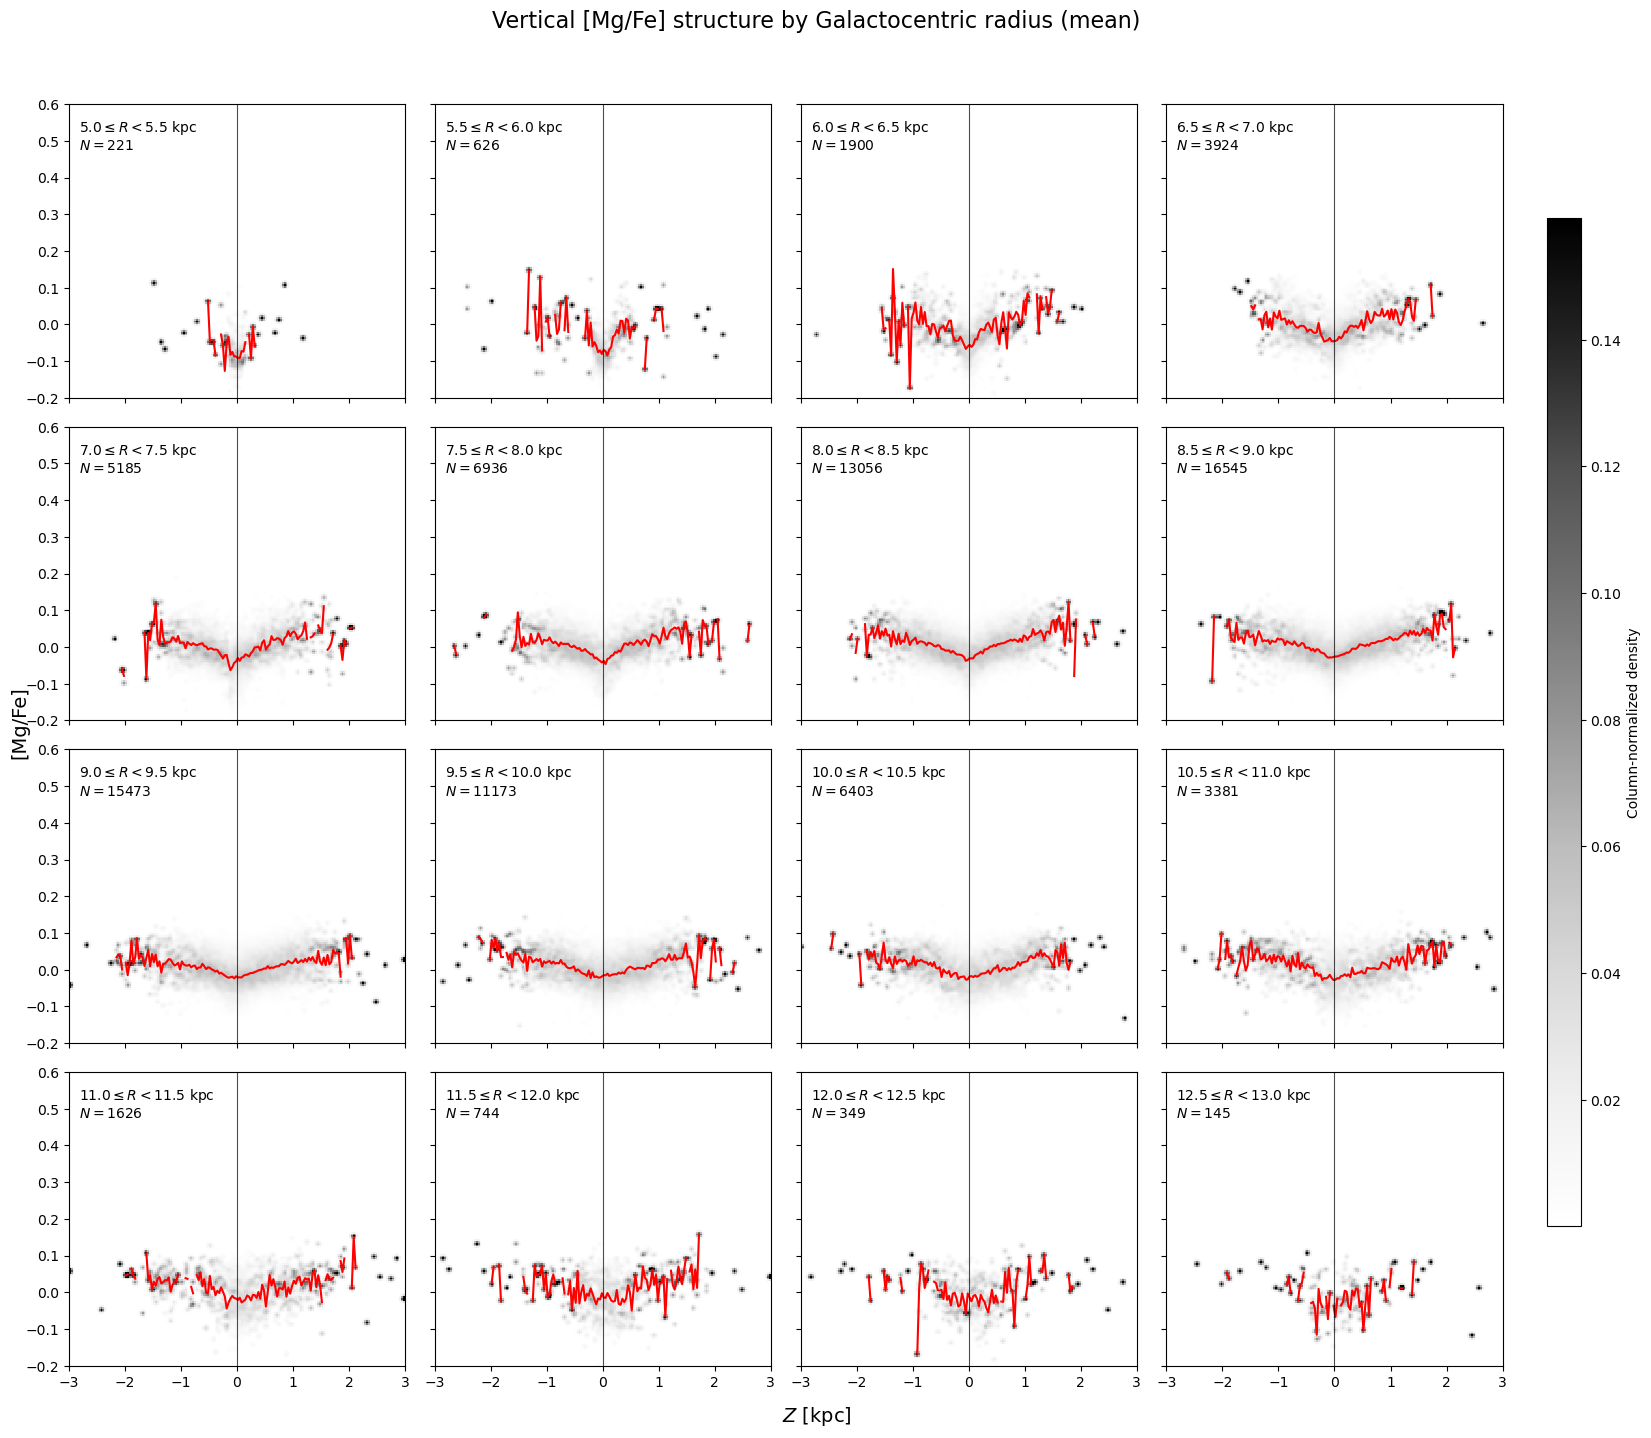

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# ============================================================
# Multi-panel annuli grid:
#   - 0.5 kpc wide annuli (as far as the data go)
#   - Skip annuli with < minN stars
#   - Column-normalized 2D histogram of Mg/Fe vs Z (signed)
#   - Light Gaussian smoothing on the image (NOT the line)
#   - Trend line = MEAN Mg/Fe in each Z bin (instead of median)
#   - Shared vmin/vmax across panels for comparability
#   - Panel labels include annulus range + N
#   - Colorbar in its own axis (no overlap)
# ============================================================

# -----------------------------
# Assumes you already have:
#   R_all   : Galactocentric cylindrical radius [kpc]
#   Z_all   : Galactocentric Z [kpc] (signed)
#   mgfe_all: [Mg/Fe]
# -----------------------------

# -----------------------------
# Controls
# -----------------------------
dR = 0.5
minN = 100

# colormap options: "viridis", "plasma", "inferno", "magma", "cividis"
cmap_name = "Greys"

# Histogram bins (shared across panels)
z_edges    = np.linspace(-3.0, 3.0, 181)    # Z bins
mgfe_edges = np.linspace(-0.2, 0.2, 81)    # Mg/Fe bins
z_centers  = 0.5 * (z_edges[:-1] + z_edges[1:])

# Smoothing (image only)
smooth_sigma = (1.0, 1.0)

# Robust color scaling percentiles
vmin_pct, vmax_pct = 2.0, 99.7

# -----------------------------
# Build annuli to span the data
# -----------------------------
Rmin_data = np.nanmin(R_all)
Rmax_data = np.nanmax(R_all)

Rstart = np.floor(Rmin_data / dR) * dR
Rstop  = np.ceil(Rmax_data / dR) * dR
all_annuli = [(r, r + dR) for r in np.arange(Rstart, Rstop, dR)]

# -----------------------------
# Precompute images, mean-trends, and N per annulus
# -----------------------------
annuli = []
imgs = []
mean_trends = []
Ns = []

for (Rmin, Rmax) in all_annuli:
    m = (R_all >= Rmin) & (R_all < Rmax)
    N = int(np.sum(m))
    if N < minN:
        continue

    Z = Z_all[m]
    mgfe = mgfe_all[m]

    # Drop NaNs just in case
    finite = np.isfinite(Z) & np.isfinite(mgfe)
    Z = Z[finite]
    mgfe = mgfe[finite]
    N = int(len(Z))
    if N < minN:
        continue

    # Column-normalized histogram: P(Mg/Fe | Z)
    H, ze, me = np.histogram2d(Z, mgfe, bins=[z_edges, mgfe_edges])  # shape (nz, nmgfe)
    colsum = H.sum(axis=1, keepdims=True)
    Hnorm  = np.divide(H, colsum, out=np.zeros_like(H), where=(colsum > 0))

    # Smooth image only (helps pixelation/speckle)
    img = gaussian_filter(Hnorm, sigma=smooth_sigma).T  # transpose -> Mg/Fe is vertical axis

    # Mean Mg/Fe in each Z bin (trend line)
    trend = np.full_like(z_centers, np.nan, dtype=float)
    for i in range(len(z_edges) - 1):
        mm = (Z >= z_edges[i]) & (Z < z_edges[i+1])
        if np.any(mm):
            trend[i] = np.nanmean(mgfe[mm])

    annuli.append((Rmin, Rmax))
    imgs.append(img)
    mean_trends.append(trend)
    Ns.append(N)

print(f"Plotted {len(annuli)} annuli with N ≥ {minN}")

# -----------------------------
# Shared color scale across panels
# -----------------------------
if len(imgs) > 0:
    vals = np.concatenate([img[(img > 0) & np.isfinite(img)] for img in imgs])
    if len(vals) > 0:
        vmin, vmax = np.percentile(vals, [vmin_pct, vmax_pct])
    else:
        vmin, vmax = 0.0, 1.0
else:
    vmin, vmax = 0.0, 1.0

# -----------------------------
# Grid layout
# -----------------------------
n_panels = len(annuli)
ncols = 4
nrows = int(np.ceil(n_panels / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4.2 * ncols, 3.6 * nrows),
    sharex=True, sharey=True
)
axes = np.atleast_2d(axes)

# -----------------------------
# Plot panels
# -----------------------------
pcm = None
for i, ax in enumerate(axes.flat):
    if i >= n_panels:
        ax.axis("off")
        continue

    Rmin, Rmax = annuli[i]
    img = imgs[i]
    trend = mean_trends[i]
    N = Ns[i]

    pcm = ax.pcolormesh(
        z_edges, mgfe_edges, img,
        shading="auto",
        vmin=vmin, vmax=vmax,
        cmap=cmap_name
    )

    ax.plot(z_centers, trend, color="red", lw=1.5)
    ax.axvline(0, color="k", lw=0.8, alpha=0.7)

    ax.text(
        0.03, 0.95,
        rf"${Rmin:.1f}\leq R<{Rmax:.1f}$ kpc" + "\n" + rf"$N={N}$",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )

    ax.set_xlim(-3, 3)
    ax.set_ylim(-0.2, 0.6)

# -----------------------------
# Shared labels + title
# -----------------------------
fig.supxlabel(r"$Z$ [kpc]", fontsize=14)
fig.supylabel(r"[Mg/Fe]", fontsize=14)
fig.suptitle(r"Vertical [Mg/Fe] structure by Galactocentric radius (mean)", fontsize=16, y=0.995)

# -----------------------------
# Colorbar in its own axis (no overlap)
# -----------------------------
fig.tight_layout(rect=[0.0, 0.0, 0.92, 0.97])  # reserve right margin
cax = fig.add_axes([0.935, 0.15, 0.02, 0.70])  # [left, bottom, width, height]
cbar = fig.colorbar(pcm, cax=cax)
cbar.set_label(r"Column-normalized density")

plt.show()


N stars in XY context: 87922


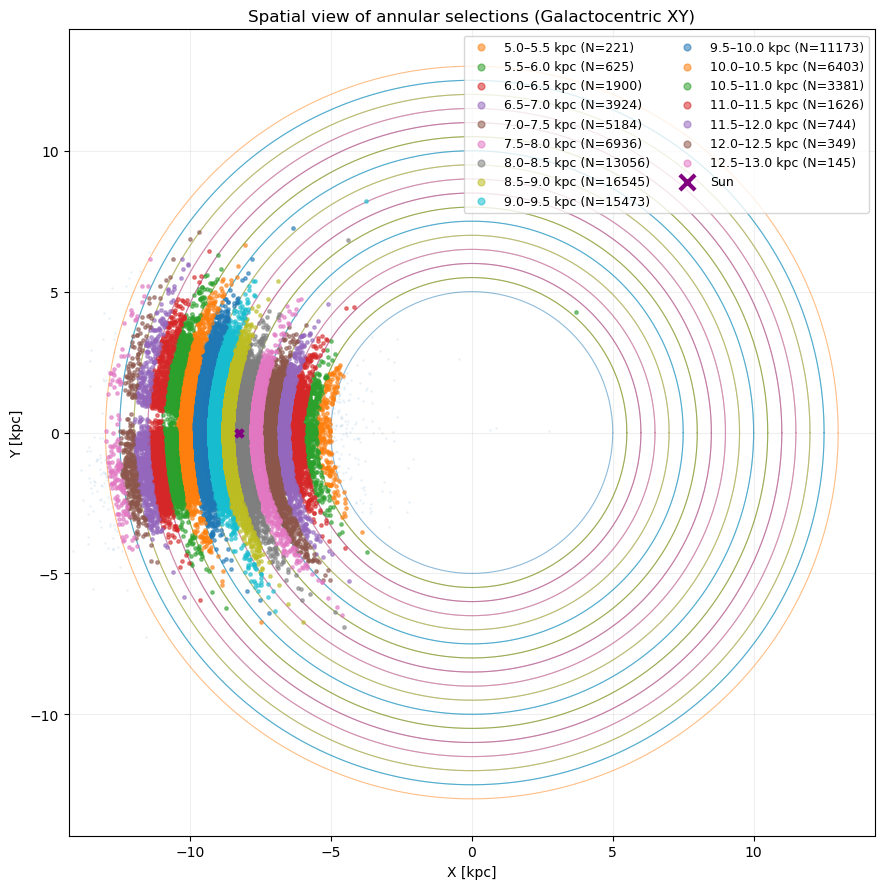

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord, Distance

# -----------------------------
# Pick final sample
# -----------------------------
t_final = t_triangle  # or t_sel

# -----------------------------
# Build Galactocentric coords
# -----------------------------
dist = Distance(np.asarray(t_final['r_med_photogeo'], float) * u.pc)  # change to u.kpc if needed

c = SkyCoord(
    ra=np.asarray(t_final['ra'], float) * u.deg,
    dec=np.asarray(t_final['dec'], float) * u.deg,
    distance=dist,
    pm_ra_cosdec=np.asarray(t_final['pmra'], float) * u.mas/u.yr,
    pm_dec=np.asarray(t_final['pmde'], float) * u.mas/u.yr,
    radial_velocity=np.asarray(t_final['v_rad'], float) * u.km/u.s,
)

galcen_frame = coord.Galactocentric(
    galcen_distance=8.275 * u.kpc,
    galcen_v_sun=[8, 254, 8] * u.km/u.s
)
gc = c.transform_to(galcen_frame)

X = gc.x.to_value(u.kpc)
Y = gc.y.to_value(u.kpc)
Z = gc.z.to_value(u.kpc)
R = np.sqrt(X**2 + Y**2)
absZ = np.abs(Z)

# -----------------------------
# Base mask (big vertical extent, finite coords)
# -----------------------------
Zmax = 5.0  # “large vertical extent”; safety cap
base_mask = np.isfinite(X) & np.isfinite(Y) & np.isfinite(R) & np.isfinite(absZ) & (absZ < Zmax)

Xb, Yb, Rb = X[base_mask], Y[base_mask], R[base_mask]

print("N stars in XY context:", len(Xb))

# -----------------------------
# Force exactly 16 annuli
# -----------------------------
n_annuli = 16
minN = 100

# Choose the radial range you want
Rmin_plot = 5.0   # kpc (edit if you want)
Rmax_plot = 13.0  # kpc (edit if you want)

# Compute edges
R_edges = np.linspace(Rmin_plot, Rmax_plot, n_annuli + 1)

annuli = []
Ns = []

for i in range(n_annuli):
    Rmin, Rmax = R_edges[i], R_edges[i+1]
    m = (Rb >= Rmin) & (Rb < Rmax)
    N = int(np.sum(m))
    if N >= minN:
        annuli.append((Rmin, Rmax))
        Ns.append(N)


# -----------------------------
# Plot: XY with annuli boundaries + highlighted stars
# -----------------------------
plt.figure(figsize=(9, 9))

# All stars in light grey (context)
plt.scatter(Xb, Yb, s=1, alpha=0.06, zorder=1)

# Circle boundaries
theta = np.linspace(0, 2*np.pi, 800)

# Draw all annulus boundaries (thin so they don't hide points)
for (Rmin, Rmax) in annuli:
    plt.plot(Rmin*np.cos(theta), Rmin*np.sin(theta), lw=0.8, alpha=0.5, zorder=2)
    plt.plot(Rmax*np.cos(theta), Rmax*np.sin(theta), lw=0.8, alpha=0.5, zorder=2)

# Highlight stars in each annulus (one scatter call per annulus)
# NOTE: we index into Xb/Yb/Rb so masks align with base_mask already applied
for (Rmin, Rmax) in annuli:
    m = (Rb >= Rmin) & (Rb < Rmax)
    N = int(np.sum(m))
    plt.scatter(Xb[m], Yb[m], s=6, alpha=0.55, zorder=3, label=f"{Rmin:.1f}–{Rmax:.1f} kpc (N={N})")

# Sun marker in Galactocentric XY:
R0 = 8.275
plt.scatter(-R0, 0, marker='x', s=30, c='purple', linewidths=3, zorder=5, label="Sun")

plt.gca().set_aspect("equal", "box")
plt.xlabel("X [kpc]")
plt.ylabel("Y [kpc]")
plt.title("Spatial view of annular selections (Galactocentric XY)")
plt.grid(alpha=0.2)

# Use a compact legend (otherwise it can get huge)
plt.legend(markerscale=2, frameon=True, fontsize=9, ncol=2, loc="upper right")

# Nice limits: use data extent, not just rings
lim = np.nanpercentile(np.sqrt(Xb**2 + Yb**2), 99.7) * 1.15
plt.xlim(-lim, lim)
plt.ylim(-lim, lim)
plt.tight_layout()
plt.show()

N stars in XZ context: 87922


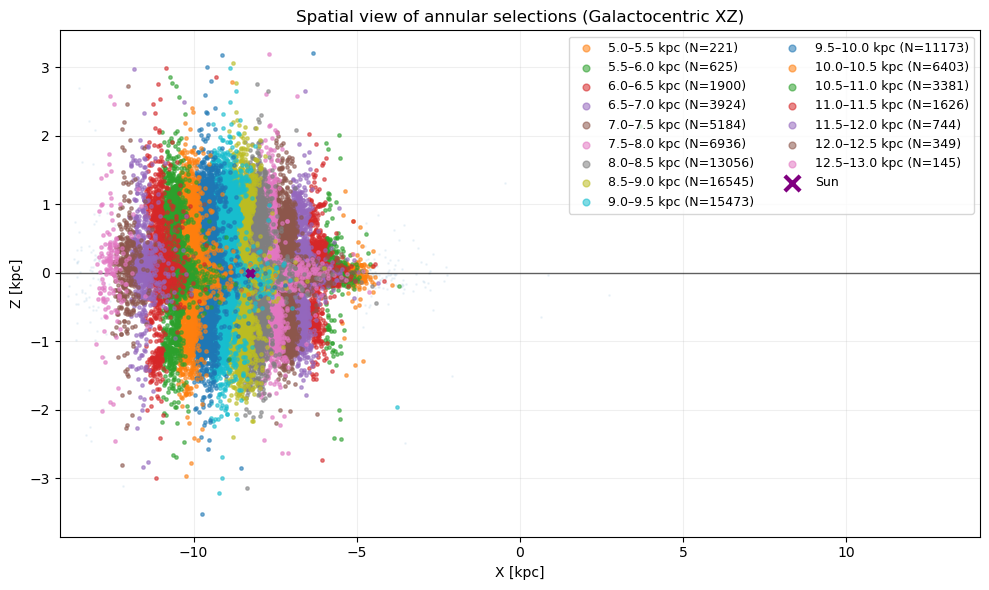

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord, Distance

# -----------------------------
# Pick final sample
# -----------------------------
t_final = t_triangle  # or t_sel

# -----------------------------
# Build Galactocentric coords
# -----------------------------
dist = Distance(np.asarray(t_final['r_med_photogeo'], float) * u.pc)  # change to u.kpc if needed

c = SkyCoord(
    ra=np.asarray(t_final['ra'], float) * u.deg,
    dec=np.asarray(t_final['dec'], float) * u.deg,
    distance=dist,
    pm_ra_cosdec=np.asarray(t_final['pmra'], float) * u.mas/u.yr,
    pm_dec=np.asarray(t_final['pmde'], float) * u.mas/u.yr,
    radial_velocity=np.asarray(t_final['v_rad'], float) * u.km/u.s,
)

galcen_frame = coord.Galactocentric(
    galcen_distance=8.275 * u.kpc,
    galcen_v_sun=[8, 254, 8] * u.km/u.s
)
gc = c.transform_to(galcen_frame)

X = gc.x.to_value(u.kpc)
Y = gc.y.to_value(u.kpc)
Z = gc.z.to_value(u.kpc)
R = np.sqrt(X**2 + Y**2)
absZ = np.abs(Z)

# -----------------------------
# Base mask (big vertical extent, finite coords)
# -----------------------------
Zmax = 5.0  # safety cap
base_mask = np.isfinite(X) & np.isfinite(Y) & np.isfinite(Z) & np.isfinite(R) & (absZ < Zmax)

Xb, Yb, Zb, Rb = X[base_mask], Y[base_mask], Z[base_mask], R[base_mask]

print("N stars in XZ context:", len(Xb))

# -----------------------------
# Force exactly 16 annuli
# -----------------------------
n_annuli = 16
minN = 100

Rmin_plot = 5.0   # kpc
Rmax_plot = 13.0  # kpc

R_edges = np.linspace(Rmin_plot, Rmax_plot, n_annuli + 1)

annuli = []
Ns = []

for i in range(n_annuli):
    Rmin, Rmax = R_edges[i], R_edges[i+1]
    m = (Rb >= Rmin) & (Rb < Rmax)
    N = int(np.sum(m))
    if N >= minN:
        annuli.append((Rmin, Rmax))
        Ns.append(N)


# -----------------------------
# Plot: XZ with highlighted stars by annulus
# -----------------------------
plt.figure(figsize=(10, 6))

# All stars in light grey (context)
plt.scatter(Xb, Zb, s=1, alpha=0.06, zorder=1)

# Highlight stars in each annulus
for (Rmin, Rmax) in annuli:
    m = (Rb >= Rmin) & (Rb < Rmax)
    N = int(np.sum(m))
    plt.scatter(Xb[m], Zb[m], s=6, alpha=0.55, zorder=3,
                label=f"{Rmin:.1f}–{Rmax:.1f} kpc (N={N})")

# Midplane line
plt.axhline(0, color="k", lw=1, alpha=0.6)

# Sun marker (approx)
R0 = 8.275
plt.scatter(-R0, 0, marker="x", s=30, c="purple", linewidths=3, zorder=5, label="Sun")

plt.xlabel("X [kpc]")
plt.ylabel("Z [kpc]")
plt.title("Spatial view of annular selections (Galactocentric XZ)")
plt.grid(alpha=0.2)

# Limits: use robust percentiles so outliers don’t blow up the view
xlim = np.nanpercentile(np.abs(Xb), 99.7) * 1.15
zlim = np.nanpercentile(np.abs(Zb), 99.7) * 1.15
plt.xlim(-xlim, xlim)
#plt.ylim(-zlim, zlim)

# Legend (can get huge; keep compact)
plt.legend(markerscale=2, frameon=True, fontsize=9, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()

## Jan 19